---
title: "4C"

categories:
  - Machine Learning
tags:
  - Correcting
  - Completing
  - Creating
  - Converting
---
# 4Cs

## Correcting
- outlying 데이터가 존재할 때, 이것들을 처리하는 과정
- seaborn의 FacetGrid를 이용하여 outlier의 데이터를 파악하고 처리하는 코드

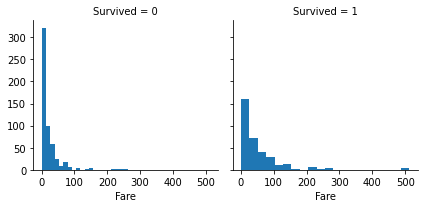

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("train.csv")
graph = sns.FacetGrid(df, col="Survived")
graph.map(plt.hist, "Fare", bins=20)

- fare 값이 400보다 큰 데이터는 outlying 하고 있다는 것을 파악할 수 있다.
- loc 을 이용하여 조건에 맞는 데이터(400보다 큰 데이터)를 필터링하고, 그 데이터를 중앙값으로 업데이트

In [2]:
df.loc[df["Fare"] > 400, "Fare"] = df["Fare"].median()

아래와 같이 400보다 큰 데이터는 사라진 것을 확인할 수 있다.

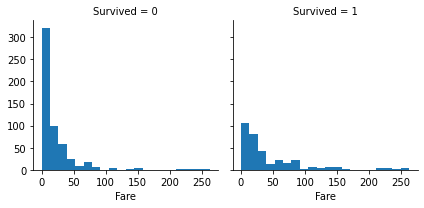

In [3]:
graph = sns.FacetGrid(df, col="Survived")
graph.map(plt.hist, "Fare", bins=20)

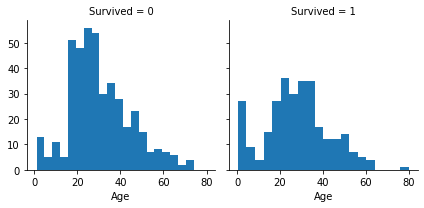

In [4]:
graph_age = sns.FacetGrid(df, col="Survived")
graph_age.map(plt.hist, "Age", bins=20)

In [5]:
df.loc[df['Age'] > 70, 'Age'] = 70

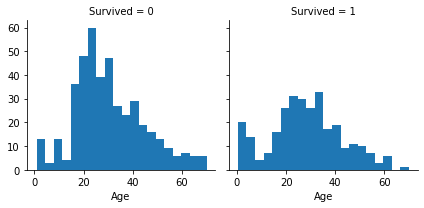

In [6]:
graph_age = sns.FacetGrid(df, col='Survived')
graph_age.map(plt.hist, 'Age', bins=20)

## Completing
- Null value들을 채워넣는 과정
  - ex) age: 그 사람의 나이를 추정하거나 median 값으로 대체

In [7]:
for column in df:
  print(column, ": ", df[column].isnull().sum()) # null 데이터 개수 column 별로 출력

PassengerId :  0
Survived :  0
Pclass :  0
Name :  0
Sex :  0
Age :  177
SibSp :  0
Parch :  0
Ticket :  0
Fare :  0
Cabin :  687
Embarked :  2


In [8]:
df['Age'].fillna(df.Age.median(), inplace = True) # inplace: Save changes


In [9]:
for column in df:
  print(column, ": ", df[column].isnull().sum()) 

PassengerId :  0
Survived :  0
Pclass :  0
Name :  0
Sex :  0
Age :  0
SibSp :  0
Parch :  0
Ticket :  0
Fare :  0
Cabin :  687
Embarked :  2


In [10]:
print(df['Embarked'].value_counts()) # number of different values

S    644
C    168
Q     77
Name: Embarked, dtype: int64


In [11]:
print(df.Pclass.value_counts())

3    491
1    216
2    184
Name: Pclass, dtype: int64


In [12]:
df.Embarked.fillna("S", inplace=True)

In [13]:
del df["Cabin"]

In [14]:
for column in df:
  print(column, ": ", df[column].isnull().sum()) 

PassengerId :  0
Survived :  0
Pclass :  0
Name :  0
Sex :  0
Age :  0
SibSp :  0
Parch :  0
Ticket :  0
Fare :  0
Embarked :  0


## Creating
- **Feature Engineering**
- 이미 존재하는 특징을 이용하여 새로운 특징을 만들어서 머신러닝 모델의 prediction power를 높여주는 과정
- 더 작은 수의 카테고리로 만들어 변수를 simplify 해 주는 기능

In [15]:
df['Name'].sample(20)

870                                    Balkic, Mr. Cerin
35                        Holverson, Mr. Alexander Oskar
401                                      Adams, Mr. John
168                                  Baumann, Mr. John D
207                          Albimona, Mr. Nassef Cassem
252                            Stead, Mr. William Thomas
199               Yrois, Miss. Henriette ("Mrs Harbeck")
454                                  Peduzzi, Mr. Joseph
298                                Saalfeld, Mr. Adolphe
529                          Hocking, Mr. Richard George
670    Brown, Mrs. Thomas William Solomon (Elizabeth ...
451                      Hagland, Mr. Ingvald Olai Olsen
59                    Goodwin, Master. William Frederick
886                                Montvila, Rev. Juozas
47                             O'Driscoll, Miss. Bridget
738                                   Ivanoff, Mr. Kanio
185                                Rood, Mr. Hugh Roscoe
412                            

위에서 Mr, Mrs, Miss 등과 같이 이름이 아닌데 이름 앞에 붙는 title을 따로 떼어내는 과정을 진행

In [16]:
def get_title(name):
  if "." in name:
    return name.split(',')[1].split(".")[0].strip()
  else:
    return "No title in name"

In [17]:
titles = set([x for x in df['Name'].map(get_title)]) # functional programming
# titles = set([x for x in df.Name.map(lambda x: get_title(x))])

In [18]:
print(titles)

{'Major', 'the Countess', 'Lady', 'Ms', 'Jonkheer', 'Master', 'Don', 'Rev', 'Col', 'Dr', 'Sir', 'Mme', 'Capt', 'Mr', 'Mlle', 'Mrs', 'Miss'}


In [19]:
def shorter_titles(x):
    title = x["Title"]
    if title in ["Capt", "Col", "Major"]:
        return "Officer"
    elif title in ["Jonkheer","Don","the Countess","Dona","Lady",'Str']:
        return "Royalty"
    elif title == "Mme":
        return "Mrs"
    elif title in ["Mlle", "Ms"]:
        return "Miss"
    else:
        return title

In [20]:
df['Title'] = df['Name'].map(get_title) # df에 Title column 자동 생성

### apply
- Series(1차원) 및 Dataframe(2차원) 타입의 객체에서 호출 가능
- 행 혹은 열 전체의 원소에 원하는 연산 적용
- axis를 통해 사라질 출 지정
  - axis = 0: 행은 사라지고 열 단위로 집계
  - axis = 1: 열은 사라지고 행 단위로 집계


아래는 Title 열을 기준으로 각각의 행 단위의 데이터에 적용하는 코드

In [21]:
df['Title'] = df.apply(shorter_titles, axis=1)

### 참고사항
#### map과 apply 함수 차이
- map 함수는 단일 column 데이터에 적용가능
- apply 함수는 단일 및 다중 column 데이터에 적용가능

결과는 아래와 같다.

In [22]:
print(df.Title.value_counts())

Mr         517
Miss       185
Mrs        126
Master      40
Dr           7
Rev          6
Officer      5
Royalty      4
Sir          1
Name: Title, dtype: int64


In [23]:
df.drop("Name", axis=1, inplace=True)

 name이 사라진 것을 확인할 수 있다.

In [24]:
df.sample(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
821,822,1,3,male,27.0,0,0,315098,8.6625,S,Mr
660,661,1,1,male,50.0,2,0,PC 17611,133.6500,S,Dr
682,683,0,3,male,20.0,0,0,6563,9.2250,S,Mr
533,534,1,3,female,28.0,0,2,2668,22.3583,C,Mrs
119,120,0,3,female,2.0,4,2,347082,31.2750,S,Miss
633,634,0,1,male,28.0,0,0,112052,0.0000,S,Mr
517,518,0,3,male,28.0,0,0,371110,24.1500,Q,Mr
5,6,0,3,male,28.0,0,0,330877,8.4583,Q,Mr
478,479,0,3,male,22.0,0,0,350060,7.5208,S,Mr
760,761,0,3,male,28.0,0,0,358585,14.5000,S,Mr


## Converting
- 컴퓨터가 학습하기 위해서 데이터들을 모두 **"Numerical"**한 숫자로 표현하는 과정
  - ex) male = 0, female = 1

In [25]:
df.Sex.replace(('male', 'female'), (0,1), inplace = True) # 순서는 중요하지 않은 변수

In [26]:
df.Embarked.value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [27]:
df.Embarked.replace(('S','C','Q'), (0,1,2), inplace = True)

In [28]:
df.Title.replace(('Mr','Miss','Mrs','Master','Dr','Rev','Officer','Royalty','Sir'), (0,1,2,3,4,5,6,7,8), inplace=True)

In [29]:
df.sample(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
551,552,0,2,0,27.0,0,0,244358,26.0000,0,0
56,57,1,2,1,21.0,0,0,C.A. 31026,10.5000,0,1
664,665,1,3,0,20.0,1,0,STON/O 2. 3101285,7.9250,0,0
639,640,0,3,0,28.0,1,0,376564,16.1000,0,0
504,505,1,1,1,16.0,0,0,110152,86.5000,0,1
799,800,0,3,1,30.0,1,1,345773,24.1500,0,2
837,838,0,3,0,28.0,0,0,392092,8.0500,0,0
360,361,0,3,0,40.0,1,4,347088,27.9000,0,0
467,468,0,1,0,56.0,0,0,113792,26.5500,0,0
483,484,1,3,1,63.0,0,0,4134,9.5875,0,2
